### Acqusition testing
Given we can now generate accurate gold codes, we now need to perform acquisition, searching through SV, frequency offset and code phase to find a correlation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import random
#stack overflow, use the PRN generator we already used and tested
module_path = os.path.abspath(os.path.join('..', 'test'))

# Add to sys.path if not already present
if module_path not in sys.path:
    sys.path.append(module_path)
import ca_code_gen


In [2]:
oversample_ratio = 4.0
num_symbols = 4100
phase_flip = 20 #BPSK every 20
chip_rate = 1.023e6

#for testing, lets constrain options

#num_svs_range = [1, 4]
#snr_range_db = [-10, -20]
#code_phase_error_range = [0, 1023];
#freq_error_range_hz = [-5000, 5000];
#sv_search_range = [1, ca_code_gen.num_sv()]

num_svs_range = [1, 1]
snr_range_db = [-10, -20]
code_phase_error_range = [0, 1023];
freq_error_range_hz = [0, 0];
sv_search_range = [1, 1]



### Generate Impairments
some imparemenets to worry about:
1. AWGN Noise in different powers
2. code phase offset (circular shift in the time domain)
3. frequency error (fake doppler)
4. unknown SV
5. Multiple SV's (co-channel)

In [3]:
#generate a random set to search
num_svs = random.randint(num_svs_range[0], num_svs_range[1])
print(f"Number sats for test: {num_svs}")
sv_array = np.zeros(num_svs)
target_snr_db_array = np.zeros(num_svs)
target_snr_lin_array = np.zeros(num_svs)
code_phase_error_array = np.zeros(num_svs)
freq_error_hz_array = np.zeros(num_svs)
for i in range(num_svs):
    if(i == 0):
        new_sv = random.randint(1, sv_search_range[1])
    else:
        #should only have one of each sv, make sure we don't have duplicates
        while True:
            new_sv = random.randint(1, sv_search_range[1])    
            if(np.size(np.where(sv_array == new_sv)) == 0):
                break
    sv_array[i] = new_sv
    target_snr_db_array[i] = random.randint(snr_range_db[1], snr_range_db[0])
    target_snr_lin_array[i] = 10.0**(target_snr_db_array[i]/10)
    code_phase_error_array[i] = random.randint(code_phase_error_range[0], int(code_phase_error_range[1]* oversample_ratio))
    freq_error_hz_array[i] = random.randint(freq_error_range_hz[0], freq_error_range_hz[1])
    print(f"Selected target SNR (db) : {target_snr_db_array[i]}")
    print(f"Target Code Phase Error (chips): {code_phase_error_array[i]/oversample_ratio}")
    print(f"Target Freq Error (Hz): {freq_error_hz_array[i]}" )
    print(f"Target SV: {sv_array[i]}")    


Number sats for test: 1
Selected target SNR (db) : -17.0
Target Code Phase Error (chips): 294.0
Target Freq Error (Hz): 0.0
Target SV: 1.0


In [4]:
upsampled_sym_len = 1023*int(oversample_ratio)

synthetic_data_array = np.zeros((num_svs, upsampled_sym_len*(num_symbols)), dtype=complex)

for sat_idx in range(num_svs):
    original_prn_biphase = np.array(ca_code_gen.PRN(int(sv_array[sat_idx])), dtype=complex)*2 -1
    oversampled_prn_cmplx = np.repeat(original_prn_biphase, int(oversample_ratio))
    phase_state = 1.0;
    for i in range(num_symbols):
        if i % phase_flip == 0:
            if(phase_state == 1):
                phase_state=-1.0
            else:
                phase_state=1.0
            #print(f"At symbol {i} phase state {phase_state}")
        synthetic_data_array[sat_idx][i*upsampled_sym_len:(i*upsampled_sym_len)+upsampled_sym_len] = oversampled_prn_cmplx*phase_state
    total_num_samples = len(synthetic_data_array[sat_idx])

    code_error_prefix = synthetic_data_array[sat_idx][0:int(code_phase_error_array[sat_idx])]
    modulated_osamp_prn_error = np.concatenate((synthetic_data_array[sat_idx][int(code_phase_error_array[sat_idx]):], code_error_prefix))

    #cross_correlate_check = np.correlate(synthetic_data_array[sat_idx], oversampled_prn_cmplx)
    #cross_correlate_check_error = np.correlate(modulated_osamp_prn_error, oversampled_prn_cmplx)
    
    synthetic_data_array[sat_idx] = modulated_osamp_prn_error
    #fig, ((ax0, ax1, ax2),(ax3, ax4, ax5)) = plt.subplots(2, 3, layout='constrained')
    #ax0.plot(np.real(cross_correlate_check/oversample_ratio)[:int(len(original_prn_biphase)/20)],'.') #dividing by the osamp ratio here.
    #ax1.plot(np.real(cross_correlate_check/oversample_ratio)[:int(len(original_prn_biphase)*oversample_ratio)]) #dividing by the osamp ratio here.
    #ax2.plot(np.real(cross_correlate_check/oversample_ratio))

    #ax3.plot(np.real(cross_correlate_check_error/oversample_ratio)[:int(len(original_prn_biphase)/20)],'.') #dividing by the osamp ratio here.
    #ax4.plot(np.real(cross_correlate_check_error/oversample_ratio)[:int(len(original_prn_biphase)*oversample_ratio)]) #dividing by the osamp ratio here.
    #ax5.plot(np.real(cross_correlate_check_error/oversample_ratio))

    #plt.show()

In [5]:
chip_period = 1/chip_rate
sample_period = chip_period/oversample_ratio
synthetic_freq_array = np.zeros((num_svs, upsampled_sym_len*(num_symbols)), dtype=complex)
#generate frequency phasor for each frequency error term
time_array = np.arange(upsampled_sym_len*num_symbols, dtype=complex) * sample_period
for sat_idx in range(num_svs):
    synthetic_freq_array[sat_idx] = np.cos(2*np.pi*freq_error_hz_array[sat_idx]*time_array) + 1j*np.sin(2*np.pi*freq_error_hz_array[sat_idx]*time_array)
    #fig, (ax0,ax1) = plt.subplots(1, 2, layout='constrained')
    #ax0.plot(np.real(synthetic_freq_array[sat_idx][0:1000]))
    #ax0.plot(np.imag(synthetic_freq_array[sat_idx][0:1000]))
    
    #ax1.plot(np.real(synthetic_freq_array[sat_idx]))
    #ax1.plot(np.imag(synthetic_freq_array[sat_idx]))
    #plt.show()
    

In [6]:
#signal_power = np.mean(np.abs(modulated_osamp_prn)**2)
#print(f"Signal Power: {signal_power}")
synthetic_noise_array = np.zeros((num_svs, upsampled_sym_len*(num_symbols)), dtype=complex)
for sat_idx in range(num_svs):
    noise_real = np.random.normal(0, np.sqrt(2)/2, total_num_samples) 
    noise_imag = np.random.normal(0, np.sqrt(2)/2, total_num_samples) 
    noise_signal = noise_real + 1j*noise_imag
    noise_signal_scaled = noise_signal * np.sqrt(1/target_snr_lin_array[sat_idx])
    #noise_power = np.mean(np.abs(noise_signal)**2)
    #noise_power_scaled = np.mean(np.abs(noise_signal_scaled)**2)
    synthetic_noise_array[sat_idx] = noise_signal_scaled
    #power_fft = np.abs(np.fft.fftshift(np.fft.fft(synthetic_data_array[sat_idx])))
    #noise_fft = np.abs(np.fft.fftshift(np.fft.fft(synthetic_noise_array[sat_idx])))
    #fig, (ax0) = plt.subplots(1, 1, layout='constrained')
    #ax0.plot(power_fft)
    #ax0.plot(noise_fft)
    #plt.show()


### stack the signal all together
For each of the satellite signals:
Now apply to the frequency error to the time domain data (with code phase error) and then add noise. Just check the properties of the noise and signal when adding them together.

In [7]:
#apply freq offset to base signals
time_freq_signal_array = synthetic_data_array * synthetic_freq_array
#for each satellite, add the noise, then normalise (so that when we sum everything, the signal + noise is all around the same power)
combined_noisy_signal = np.zeros(upsampled_sym_len*(num_symbols), dtype=complex)

for sv_idx in range(num_svs):
    print(f"SV IDX: {sv_idx}")
    signal_power = np.mean(np.abs(time_freq_signal_array[sv_idx])**2)
    noise_power = np.mean(np.abs(synthetic_noise_array[sv_idx])**2)
    sv_noisy_signal = time_freq_signal_array[sv_idx] + synthetic_noise_array[sv_idx]
    combined_sv_power = np.mean(np.abs(sv_noisy_signal)**2)
    norm_sv_noisy_signal = sv_noisy_signal * np.sqrt(1/combined_sv_power)
    combined_noisy_signal += norm_sv_noisy_signal;
    norm_power = np.mean(np.abs(norm_sv_noisy_signal)**2)
    print(f"Signal Power: {10*np.log10(signal_power)} Noise Power: {10*np.log10(noise_power)}")
    print(f"S+N Signal Power: {10*np.log10(combined_sv_power)} Norm Signal Power: {10*np.log10(norm_power)}")

total_signal_power = np.mean(np.abs(combined_noisy_signal)**2)
print(f"Total Signal Power: {total_signal_power}")

SV IDX: 0
Signal Power: 0.0 Noise Power: 17.00046756141625
S+N Signal Power: 17.086204721611765 Norm Signal Power: -9.161110932256236e-15
Total Signal Power: 0.9999999999999979


In [8]:
#plt.plot(np.abs(combined_noisy_signal))

### Now perform the receiving
Take I and Q channels and perform 1 bit quantise in I and Q around 0
compare to floating point correlation implementation
search, fastest to slowest, code phase, freq, sv (assumes SV's will hang around and freq changes slowlyish)

In [9]:
i_chan_quantised = np.array(np.where(np.real(combined_noisy_signal) >= 0.0, 1,-1),dtype="int8")
q_chan_quantised = np.array(np.where(np.imag(combined_noisy_signal) >= 0.0, 1,-1),dtype="int8")

In [10]:
code_phase_search_steps = 1023
freq_search_range_hz = [-500, 500]
freq_search_step_hz = 250
sv_search_steps = 1 #
#sv_search_steps = ca_code_gen.num_sv()

num_freq_search_steps = int(np.ceil((freq_search_range_hz[1] - freq_search_range_hz[0])/freq_search_step_hz))

freq_search_step_array = np.linspace(freq_search_range_hz[0], freq_search_range_hz[1], num_freq_search_steps,endpoint=True)

total_num_searches = code_phase_search_steps*num_freq_search_steps*sv_search_steps
print(f"Code Searches: {code_phase_search_steps} Freq Searches: {num_freq_search_steps} SV Searches: {sv_search_steps} Total Searches: {total_num_searches}")

total_search_samples = total_num_searches*code_phase_search_steps*oversample_ratio
total_search_time = total_search_samples*sample_period

print(f"Search requires {total_search_samples} samples, {total_search_time} seconds")
print(f"Length of generated data: {np.size(combined_noisy_signal)}, {np.size(combined_noisy_signal) * sample_period} seconds")
#each code phase search needs this many samples
code_idx_samples_step = int(code_phase_search_steps*oversample_ratio) 
#each freq index needs this many samples
freq_idx_samples_step = int(code_phase_search_steps*code_idx_samples_step)
#each svindex needs this manu samples
sv_idx_samples_step = int(freq_idx_samples_step*num_freq_search_steps)

magsq_results_table = np.zeros((sv_search_steps, num_freq_search_steps, code_phase_search_steps),dtype="int32")

correction_time_array = np.arange(int(code_phase_search_steps*oversample_ratio), dtype=complex) * sample_period

for sv_idx in range(sv_search_steps):
    #generate a base oversampled code for this set of tests
    regenerated_prn = np.array(ca_code_gen.PRN(int(sv_array[sv_idx])), dtype=complex)*2 -1
    regenerated_prn_cmplx = np.repeat(original_prn_biphase, int(oversample_ratio))
    regenerated_prn_i = np.array(np.where(np.real(regenerated_prn_cmplx) >= 0.0, 1,-1),dtype="int8")
    regenerated_prn_q = np.array(np.where(np.imag(regenerated_prn_cmplx) >= 0.0, 1,-1),dtype="int8")
    
    for freq_idx in range(num_freq_search_steps):
        #generate a quantised complex phasor for derotation        
        correction_phasor = np.cos(2*np.pi*freq_search_step_array[freq_idx]*correction_time_array) + 1j*np.sin(2*np.pi*freq_search_step_array[freq_idx]*correction_time_array)
        regenerated_correction_i = np.array(np.where(np.real(correction_phasor) >= 0.0, 1,-1), dtype="int8")
        regenerated_correction_q = np.array(np.where(np.imag(correction_phasor) >= 0.0, 1,-1), dtype="int8")
        
        for code_idx in range(code_phase_search_steps):
#perform cyclic rotation on code (take code_idx*oversample samples from front and put at back)
            test_prn_i = np.concatenate((regenerated_prn_i[int(code_idx*oversample_ratio):],regenerated_prn_i[0:int(code_idx*oversample_ratio)]))
            test_prn_q = np.concatenate((regenerated_prn_q[int(code_idx*oversample_ratio):],regenerated_prn_q[0:int(code_idx*oversample_ratio)]))
            #find chunk of time domain samples relating to this search
            start_sample_idx = int(sv_idx*sv_idx_samples_step+freq_idx*freq_idx_samples_step+code_idx*code_idx_samples_step)
            search_samples_i = i_chan_quantised[start_sample_idx:start_sample_idx+code_idx_samples_step]
            search_samples_q = q_chan_quantised[start_sample_idx:start_sample_idx+code_idx_samples_step]
            #apply frequency derotation
            rotated_test_i = test_prn_i * regenerated_correction_i
            rotated_test_q = test_prn_q * regenerated_correction_q
            #perform correlation in time domain by multiplying the 
            search_correlation_metric_i = np.sum(search_samples_i * rotated_test_i)
            search_correlation_metric_q = np.sum(search_samples_q * rotated_test_q)
            magsq_results_table[sv_idx][freq_idx][code_idx] = search_correlation_metric_i*search_correlation_metric_i+search_correlation_metric_q*search_correlation_metric_q#print(f"Search Code: {code_idx} Freq: {freq_idx} SV {sv_idx} I val {search_correlation_metric_i} Q val {search_correlation_metric_q}")


Code Searches: 1023 Freq Searches: 4 SV Searches: 1 Total Searches: 4092
Search requires 16744464.0 samples, 4.092 seconds
Length of generated data: 16777200, 4.1 seconds


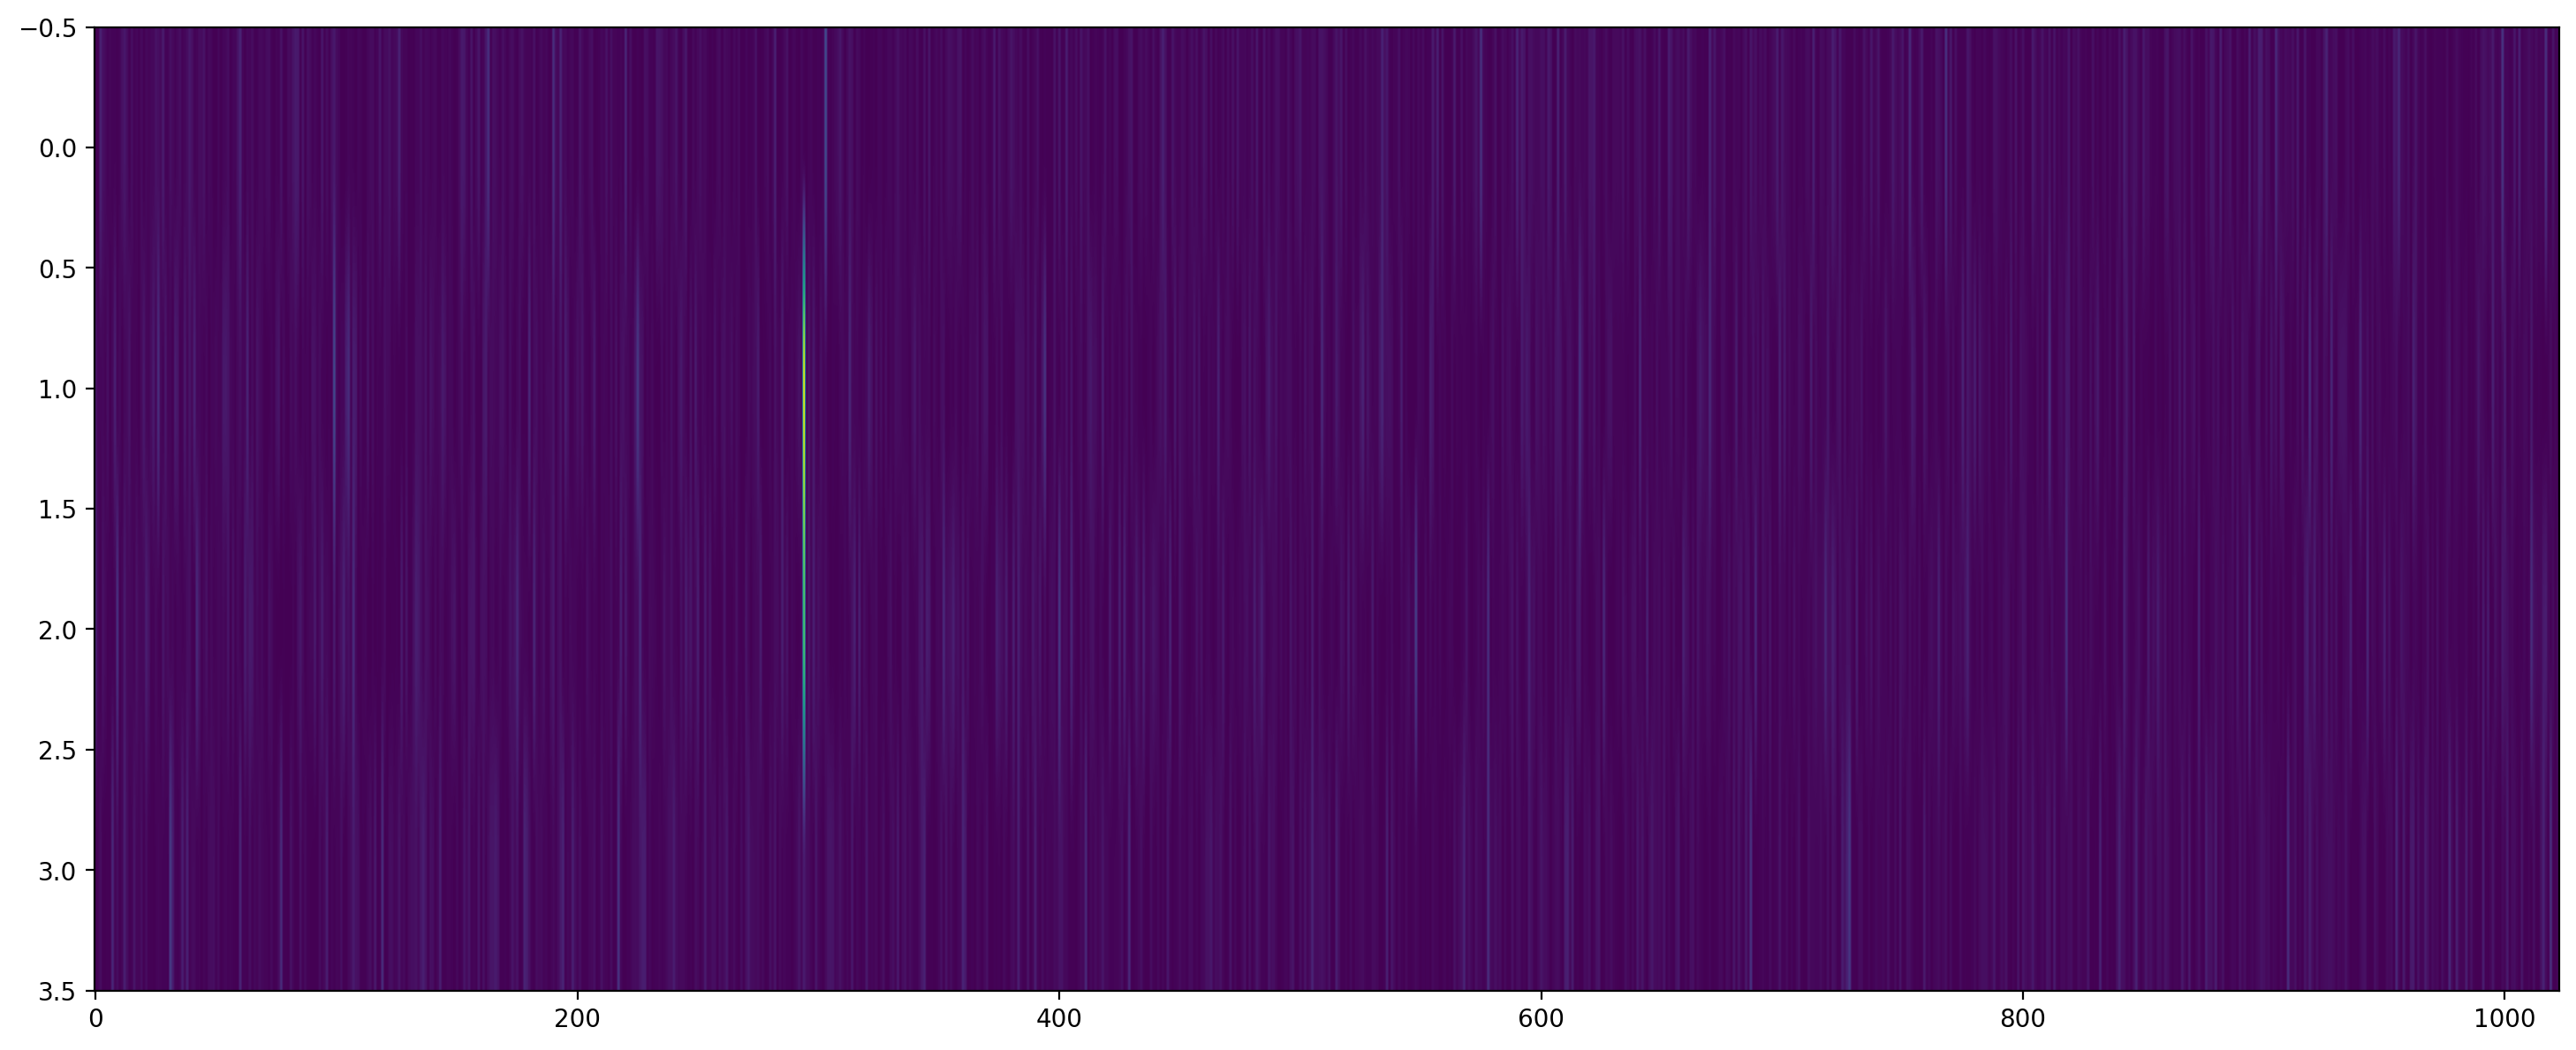

(4, 1023)

In [11]:
fig, ax = plt.subplots(figsize=(18, 18))
ax.imshow(magsq_results_table[0], aspect=100)
plt.show()
np.shape(magsq_results_table[0])

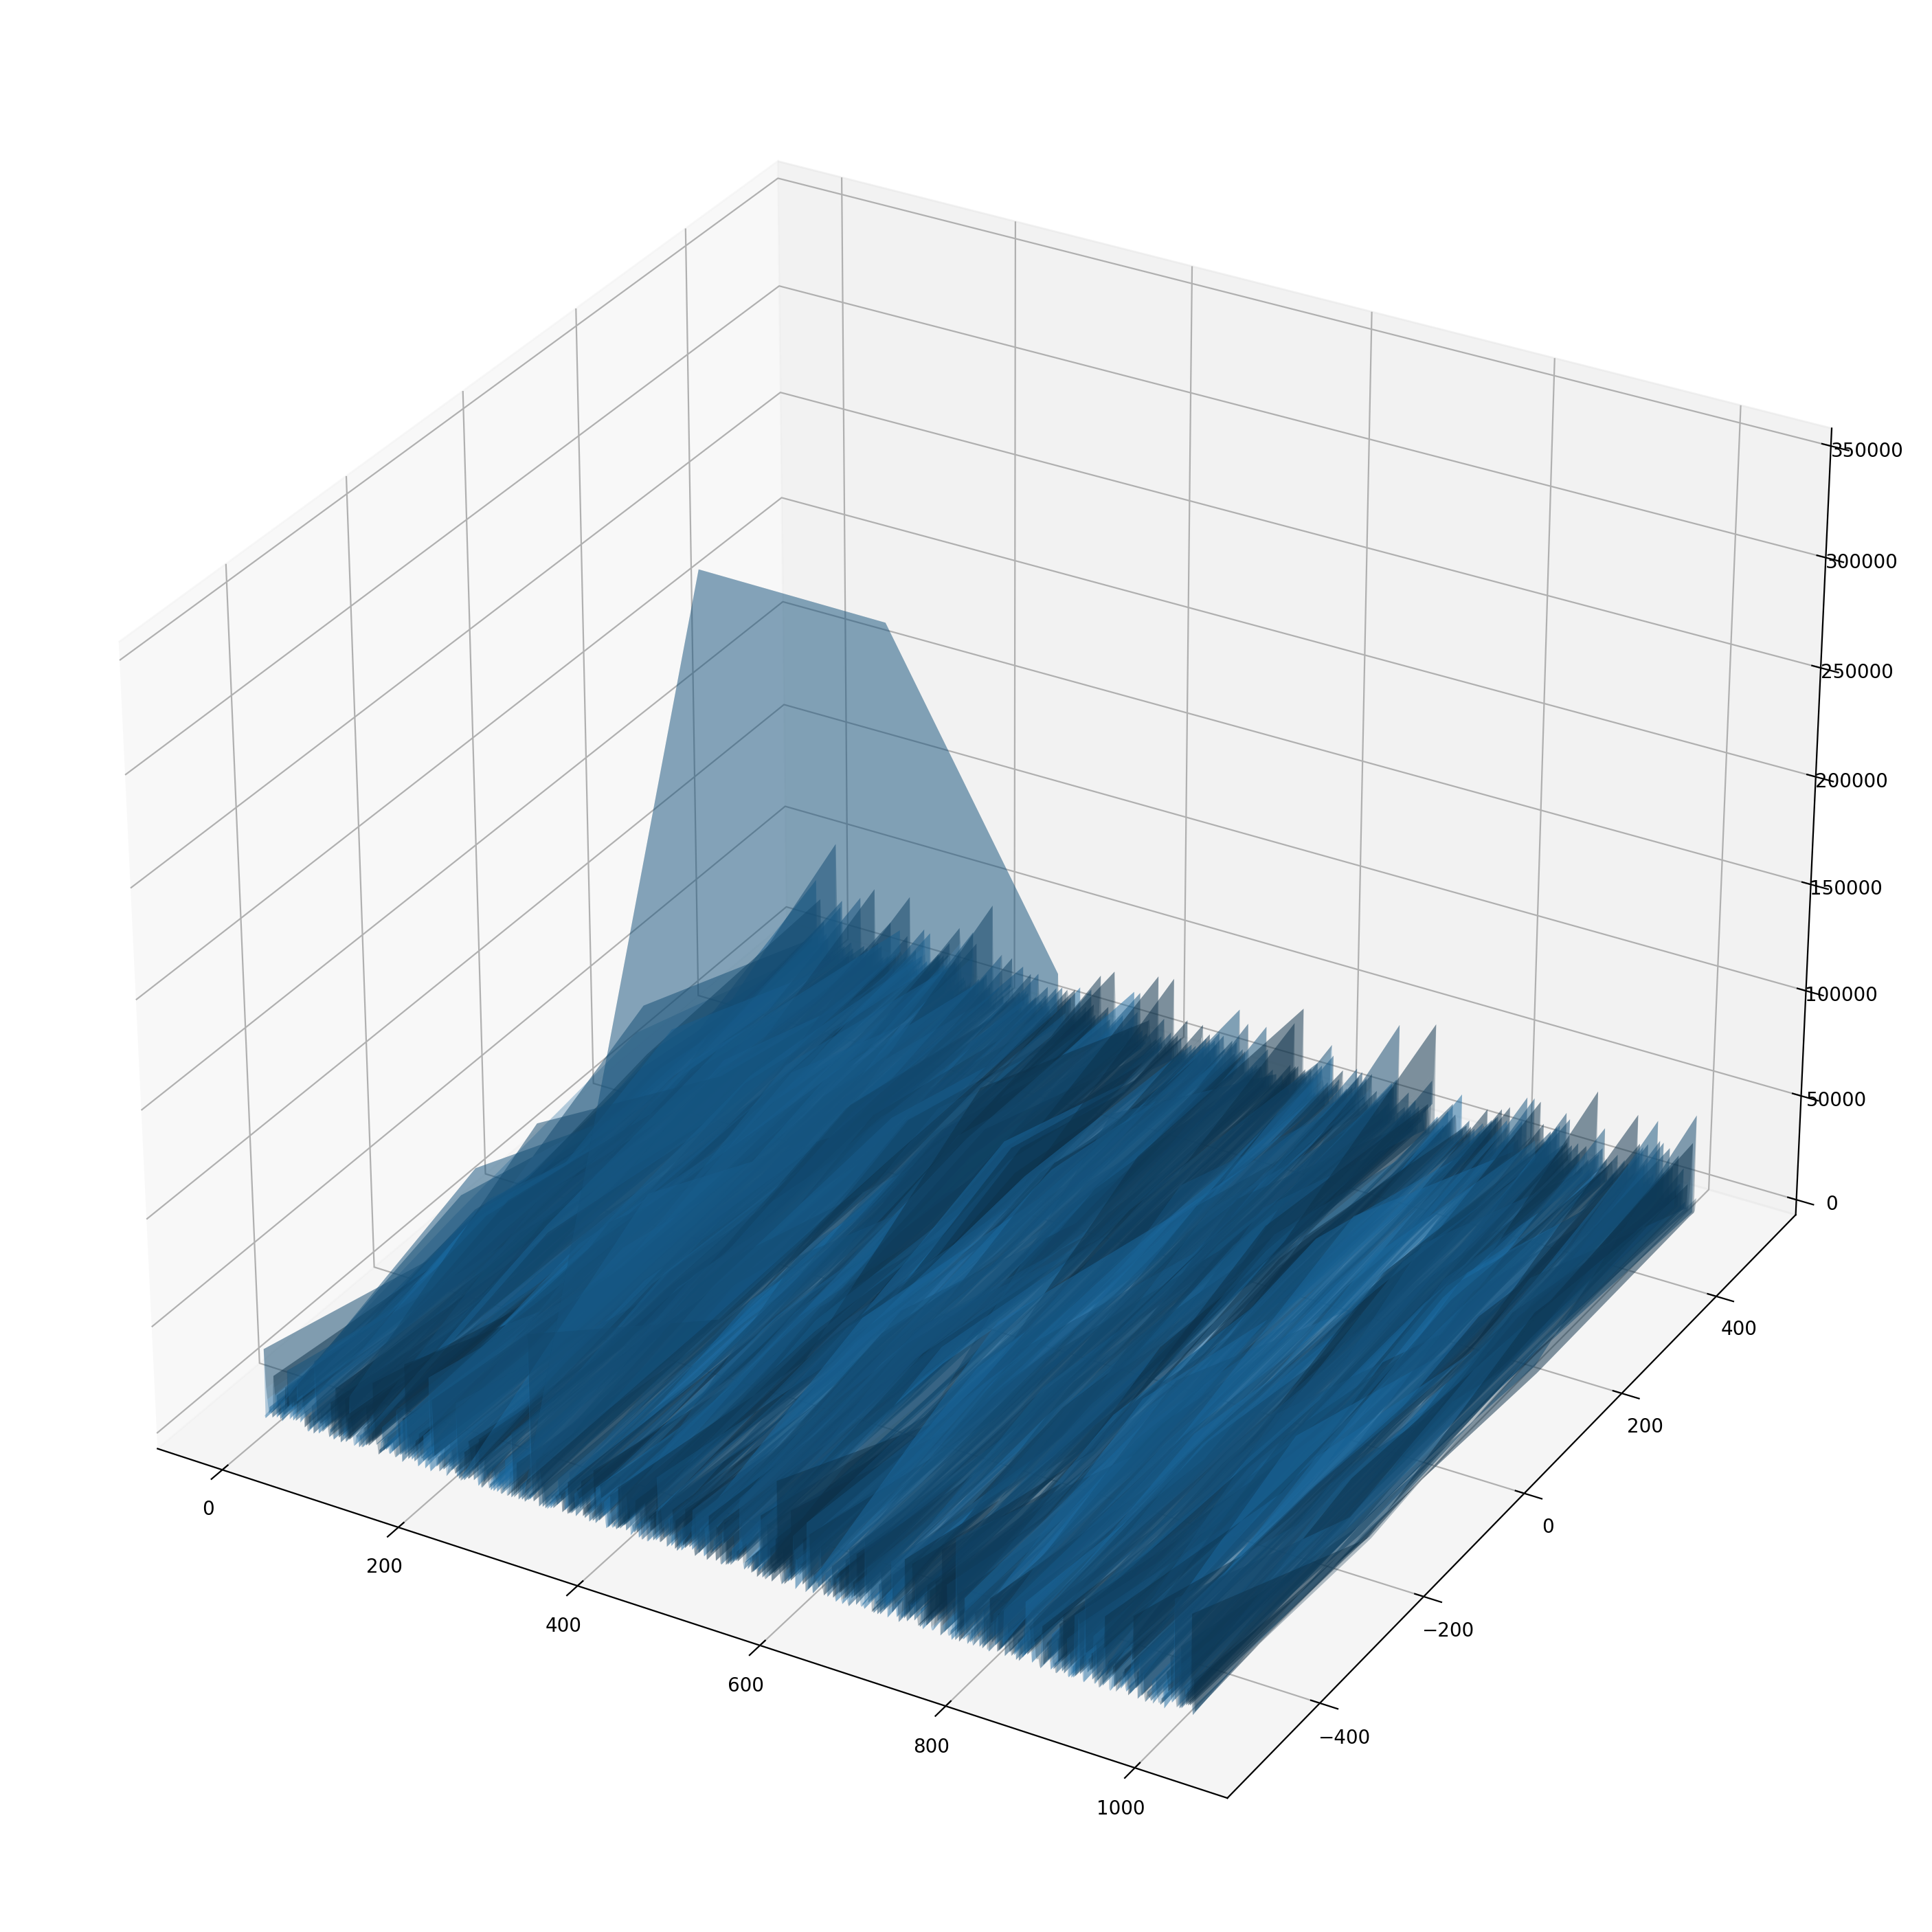

In [23]:
ax = plt.figure(figsize=(18,18)).add_subplot(projection='3d')
code_array = np.arange(code_phase_search_steps)
X, Y = np.meshgrid(code_array, freq_search_step_array)
ax.plot_surface(X, Y, magsq_results_table[0], alpha=0.3, lw=0.5, rstride=10, cstride=1)
plt.show()